# Step 4 - The ARIMA pipeline

This is one of four `step4_model_*` notebooks, one per model architecture. Read them after step 1 (data splitting), step 2 (cross-validation), and step 5 (hyperparameter tuning -- demoed on `prophet_xgb`). Step 5 shows *where* a final set of hyperparameters comes from; here we fit the model with the package defaults from `params.yaml` and inspect its behavior. To run this notebook with tuned parameters instead, pass `config_overrides={"models": {"arima": best_params}}` into `run_single_its()`.

**Goal:** walk through `run_single_its()` using the `ARIMAModel`.

Sections:
- **4a.** Load the pre-built dummy data.
- **4b.** Fit `ARIMAModel` manually and inspect the `FitResult`.
- **4c.** Inside ARIMA -- automatic order selection and in-sample fit.
- **4d.** Run the full pipeline via `run_single_its()`.
- **4e.** Inspect `PipelineResult`: metrics, excess table, ATE.
- **4f.** Reproduce the counterfactual plot with annotations.

In [1]:
%matplotlib inline

from IPython.display import display
import logging
import warnings
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s  %(levelname)s  %(name)s - %(message)s",
    datefmt="%H:%M:%S",
)
logging.getLogger("cmdstanpy").setLevel(logging.WARNING)
logging.getLogger("its2s").setLevel(logging.WARNING)

OUT_DIR = Path.cwd() / "figures"
OUT_DIR.mkdir(exist_ok=True)
INTERVENTION = "2022-03-15"
TEST_DAYS    = 365
HOLDOUT_DAYS = 42

## 4a. Load the pre-built dummy data

The series has a +8/day intervention effect baked in for 42 days after 2022-03-15.

In [2]:
df = pd.read_csv("data/dummy_data.csv", parse_dates=["ds"])

print("=" * 60)
print("Dummy dataset (with +8/day intervention effect)")
print("=" * 60)
print(df.tail())

Dummy dataset (with +8/day intervention effect)
             ds          y  covar_linear  covar_dow  covar_noise
1571 2022-04-21  71.975041      0.995182        3.0    -0.356611
1572 2022-04-22  73.042307      1.033630        4.0     0.247103
1573 2022-04-23  72.275013      1.003513        5.0     1.129482
1574 2022-04-24  69.332534      1.004775        6.0    -0.321536
1575 2022-04-25  69.651058      0.981820        0.0    -1.057655


## 4b. Fit `ARIMAModel` manually

This replicates what `run_single_its` does internally, so we can inspect the `FitResult`.

In [3]:
from its2s.data_prep import prepare_splits
from its2s.models.arima import ARIMAModel
from its2s.settings import get_model_config, load_config

config = load_config()
splits = prepare_splits(df, INTERVENTION, test_days=TEST_DAYS, holdout_days=HOLDOUT_DAYS)

model_params = get_model_config(config, "arima")
model = ARIMAModel(params=model_params)

print("Fitting ARIMAModel on training data ...")
print(f"  Training rows : {len(splits.train_df)}")
print(f"  Training range: {splits.train_df['ds'].min().date()} -> {splits.train_df['ds'].max().date()}")

fit_result = model.fit(splits.train_df, target_col="y", date_col="ds")

print("\nFitResult fields:")
print(f"  fitted_values  shape = {fit_result.fitted_values.shape}")
print(f"  residuals      shape = {fit_result.residuals.shape}")
print(f"  residuals  mean={fit_result.residuals.mean():.4f}  std={fit_result.residuals.std():.4f}")
print(f"  metadata: {fit_result.metadata}")

Fitting ARIMAModel on training data ...
  Training rows : 1227
  Training range: 2018-01-01 -> 2021-05-11



FitResult fields:
  fitted_values  shape = (1227,)
  residuals      shape = (1227,)
  residuals  mean=0.0309  std=2.5302
  metadata: {'order': (2, 1, 2), 'seasonal_order': (0, 0, 1, 7)}


## 4c. Inside ARIMA -- automatic order selection and in-sample fit

`auto_arima` selects the best `(p,d,q)` and seasonal order via stepwise search during the
initial fit. The discovered order is stored in `fit_result.metadata` and preserved by
`clone_fresh()`, so Moving Block Bootstrap refits use the same model structure without
repeating the expensive search on each simulation.

In [4]:
arima_model = fit_result.model_object

print("Discovered ARIMA order:")
print(f"  Non-seasonal (p,d,q)  : {fit_result.metadata['order']}")
print(f"  Seasonal (P,D,Q,m)    : {fit_result.metadata['seasonal_order']}")
print()
print(arima_model.summary())

Discovered ARIMA order:
  Non-seasonal (p,d,q)  : (2, 1, 2)
  Seasonal (P,D,Q,m)    : (0, 0, 1, 7)

                                      SARIMAX Results                                      
Dep. Variable:                                   y   No. Observations:                 1227
Model:             SARIMAX(2, 1, 2)x(0, 0, [1], 7)   Log Likelihood               -2636.484
Date:                             Fri, 15 May 2026   AIC                           5284.968
Time:                                     12:19:47   BIC                           5315.638
Sample:                                          0   HQIC                          5296.509
                                            - 1227                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1 

In [5]:
# clone_fresh() preserves the discovered order -- verify
fresh_clone = model.clone_fresh()
print("clone_fresh() preserves order for MBB:")
print(f"  Original  _fixed_order         : {model._fixed_order}")
print(f"  Clone     _fixed_order         : {fresh_clone._fixed_order}")
print(f"  Original  _fixed_seasonal_order: {model._fixed_seasonal_order}")
print(f"  Clone     _fixed_seasonal_order: {fresh_clone._fixed_seasonal_order}")
print()
print("When MBB fits the clone, it skips auto_arima and goes directly to pm.ARIMA(order=...)")

clone_fresh() preserves order for MBB:
  Original  _fixed_order         : (2, 1, 2)
  Clone     _fixed_order         : (2, 1, 2)
  Original  _fixed_seasonal_order: (0, 0, 1, 7)
  Clone     _fixed_seasonal_order: (0, 0, 1, 7)

When MBB fits the clone, it skips auto_arima and goes directly to pm.ARIMA(order=...)


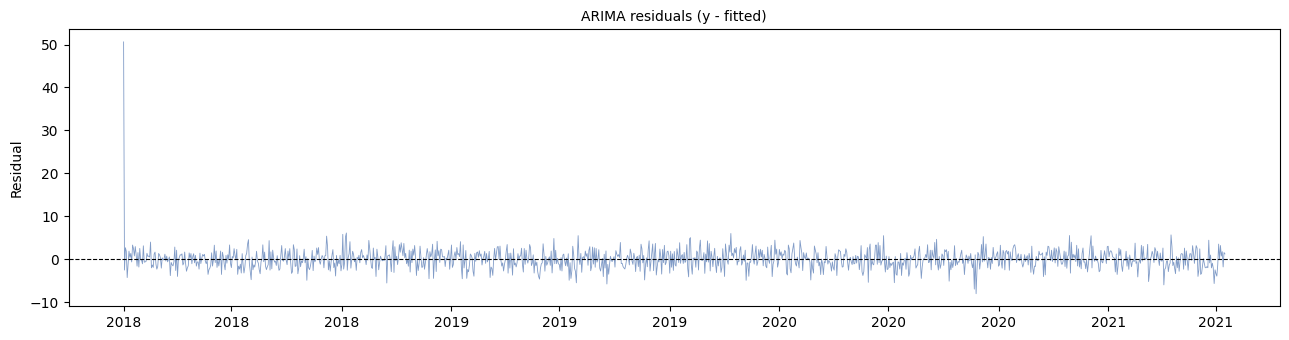

In [6]:
fig, ax = plt.subplots(figsize=(13, 3.5))
ax.plot(splits.train_df["ds"], fit_result.residuals,
        linewidth=0.6, color="#4C72B0", alpha=0.7)
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_title("ARIMA residuals (y - fitted)", fontsize=10)
ax.set_ylabel("Residual")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.tight_layout()
plt.savefig(OUT_DIR / "arima_residuals.png", dpi=150)
display(fig)

## 4d. Run the full pipeline via `run_single_its()`

MBB bootstrap runs with `n_sim=100` for speed; production use should set this to 1000+.

In [7]:
from its2s import run_single_its

result = run_single_its(
    df=df,
    intervention_date=INTERVENTION,
    model_name="arima",
    config_overrides={
        "bootstrap": {"n_sim": 100},
        "periods":   {"test_days": TEST_DAYS, "holdout_days": HOLDOUT_DAYS},
    },
    output_dir=OUT_DIR,
    seed=42,
)

print("PipelineResult fields:")
print(f"  model_name       : {result.model_name}")
print(f"  fit_result       : FitResult with {len(result.fit_result.fitted_values)} fitted values")
print(f"  bootstrap_result : BootstrapCIResult  pred_matrix shape = {result.bootstrap_result.pred_matrix.shape}")
print(f"  metrics_train    : {result.metrics_train}")
print(f"  metrics_test     : {result.metrics_test}")

PipelineResult fields:
  model_name       : arima
  fit_result       : FitResult with 1227 fitted values
  bootstrap_result : BootstrapCIResult  pred_matrix shape = (349, 100)
  metrics_train    : MetricsResult(rmse=7.5088535109714565, mae=6.461765880820249, mape=12.541930980611566, smape=12.40650136912448, mase=None, r2=-0.03152574765763427)
  metrics_test     : MetricsResult(rmse=7.407405691935696, mae=6.366891256410078, mape=12.660918366970767, smape=12.086627142613985, mase=2.7569276710091923, r2=-0.27243349416582907)


## 4e. Metrics and excess table

In [8]:
metrics_df = pd.DataFrame({
    "RMSE":  [result.metrics_train.rmse,  result.metrics_test.rmse],
    "MAE":   [result.metrics_train.mae,   result.metrics_test.mae],
    "MAPE":  [result.metrics_train.mape,  result.metrics_test.mape],
    "SMAPE": [result.metrics_train.smape, result.metrics_test.smape],
    "R2":    [result.metrics_train.r2,    result.metrics_test.r2],
}, index=["Train", "Test"])
print(metrics_df.round(3).to_string())

        RMSE    MAE    MAPE   SMAPE     R2
Train  7.509  6.462  12.542  12.407 -0.032
Test   7.407  6.367  12.661  12.087 -0.272


In [9]:
print("Period-level excess:")
print(result.excess_table.period_excess.to_string(index=False))
print("\nDaily excess - first 10 holdout days:")
print(result.excess_table.daily_excess.head(10).to_string(index=False))

Period-level excess:
      period start_date   end_date  n_days  total_observed  total_expected  total_excess  excess_ci_lo  excess_ci_hi  excess_pct
Full holdout 2022-03-15 2022-04-25      42     3029.800778      2177.55664    852.244138     67.621463    528.983714   39.137634

Daily excess - first 10 holdout days:
      date  observed  expected  expected_ci_lo  expected_ci_hi    excess  excess_ci_lo  excess_ci_hi  excess_pct  excess_pct_ci_lo  excess_pct_ci_hi
2022-03-15 76.449700 51.984130       58.997665       70.063460 24.465570      6.386241     17.452036   47.063537         12.284981         33.571853
2022-03-16 70.565458 51.976705       59.023618       70.086124 18.588753      0.479334     11.541840   35.763624          0.922210         22.205794
2022-03-17 74.032036 51.969338       59.049627       70.108788 22.062698      3.923247     14.982409   42.453298          7.549158         28.829324
2022-03-18 69.205309 51.962028       59.075689       70.131453 17.243281     -0.926144

In [10]:
from its2s.metrics.excess import calc_ate_summary

ate = calc_ate_summary(result.excess_table.daily_excess)
print("Average Treatment Effect (ATE) summary:")
print(ate.to_string(index=False))
print("\n  Total ATE      = sum of daily excess over full holdout")
print("  Mean Daily ATE = average excess per day")
print(f"  Simulated effect was +8/day for {HOLDOUT_DAYS} days -> expected total excess ~{8 * HOLDOUT_DAYS}")

Average Treatment Effect (ATE) summary:
        metric   estimate     ci_lo      ci_hi  n_days
     Total ATE 852.244138 67.608534 528.983714      42
Mean Daily ATE  20.291527  1.609727  12.594850      42

  Total ATE      = sum of daily excess over full holdout
  Mean Daily ATE = average excess per day
  Simulated effect was +8/day for 42 days -> expected total excess ~336


## 4f. Counterfactual plot (annotated)

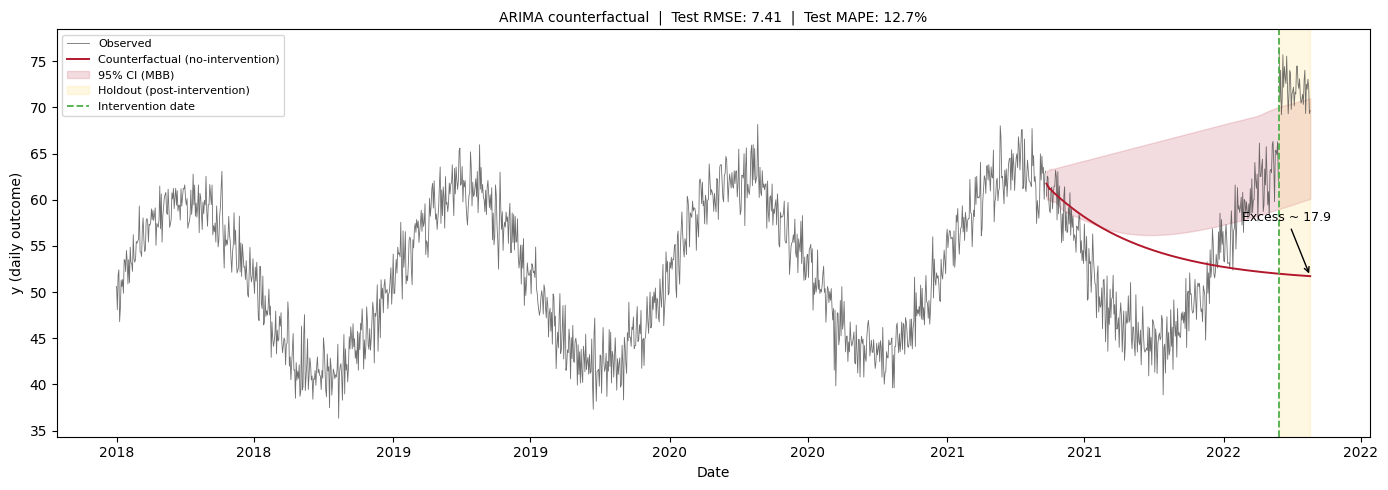

In [11]:
br = result.bootstrap_result
pred_dates = pd.to_datetime(br.dates)
intervention_ts = pd.Timestamp(INTERVENTION)

fig, ax = plt.subplots(figsize=(14, 5))

for part in [splits.train_df, splits.test_df, splits.holdout_df]:
    ax.plot(part["ds"], part["y"], color="#333333", linewidth=0.6, alpha=0.7)
ax.plot([], [], color="#333333", linewidth=0.6, alpha=0.7, label="Observed")

ax.plot(pred_dates, br.predicted, color="#B2182B", linewidth=1.4,
        label="Counterfactual (no-intervention)")
ax.fill_between(pred_dates, br.conf_lo, br.conf_hi,
                color="#B2182B", alpha=0.15, label="95% CI (MBB)")

ax.axvspan(intervention_ts, splits.holdout_df["ds"].max(),
           color="#FEE08B", alpha=0.25, label="Holdout (post-intervention)")
ax.axvline(intervention_ts, color="#4DAF4A", linestyle="--", linewidth=1.3,
           label="Intervention date")

last_date = pred_dates[pred_dates >= intervention_ts][-1]
last_obs  = splits.holdout_df.loc[splits.holdout_df["ds"] == last_date, "y"].values
last_pred = br.predicted[pred_dates == last_date]
if len(last_obs) and len(last_pred):
    ax.annotate(
        f"Excess ~ {float(last_obs[0] - last_pred[0]):.1f}",
        xy=(last_date, float(last_pred[0])),
        xytext=(last_date - pd.Timedelta(days=90), float(last_pred[0]) + 6),
        arrowprops=dict(arrowstyle="->", color="black"),
        fontsize=9,
    )

ax.set_xlabel("Date")
ax.set_ylabel("y (daily outcome)")
ax.set_title(
    f"ARIMA counterfactual  |  Test RMSE: {result.metrics_test.rmse:.2f}"
    f"  |  Test MAPE: {result.metrics_test.mape:.1f}%",
    fontsize=10,
)
ax.legend(loc="upper left", fontsize=8)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.tight_layout()
plt.savefig(OUT_DIR / "arima_counterfactual.png", dpi=150)
display(fig)

**Known issue -- smooth counterfactual curve.** The counterfactual line above appears as a smooth, monotonically declining curve rather than tracking the annual seasonal pattern visible in the observed data. This happens because `params.yaml` sets `m: 7`, so `auto_arima` searches for weekly (7-day) seasonal structure only. The dominant annual cycle (period ~ 365 days) is invisible to the model, and multi-step ARIMA forecasts without that component converge toward the long-run trend. To capture annual seasonality, set `m=365` via `config_overrides={"models": {"arima": {"m": 365}}}` — note that this increases fitting time substantially.

## Key takeaways

1. `ARIMAModel.fit()` calls `auto_arima` on the first run to discover `(p,d,q)` and seasonal order; the selected order is stored in `fit_result.metadata`.
2. `clone_fresh()` preserves the discovered order so Moving Block Bootstrap refits do not repeat the expensive stepwise search on each simulation.
3. Unlike Prophet-based models, ARIMA has no decomposition stages -- residuals are simply `y - fitted`.
4. `run_single_its()` orchestrates: `load_config -> prepare_splits -> fit -> bootstrap -> metrics -> excess -> save`.
5. Excess = observed - counterfactual_predicted. With a true +8/day effect over 42 days, total excess should land near 336 (noise aside).